# Notebook where we can see in more detail the dynamics of each one of the neuron models

In [173]:
import numpy as np
import scipy as scy
from numba import njit
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os





In [174]:
%matplotlib widget

## Models (without injection, nor delay, nor difussion)


In [175]:

class LIF():
    def __init__(self, V_rest, RC, I_inj, V_th):
        self.V_rest = V_rest
        self.RC = RC
        self.I_inj = I_inj
        self.V_th = V_th

    def dx_dt(self, K_X, X, header=None):
        # NOTE: using self.RC, not RC
        K_X[0] = ((X[0] - self.V_rest) / self.RC) + self.I_inj
        return K_X

    def threshold(self, X):
        if X[0] >= self.V_th:
            X[0] = self.V_rest
        return X


class FHN():
    def __init__(self, alpha, beta, inv_gamma, I_inj, V_th=1.0, V_reset=0.0):
        self.alpha = alpha
        self.beta = beta
        self.inv_gamma = inv_gamma
        self.I_inj = I_inj
        self.V_th = V_th
        self.V_reset = V_reset

    def dx_dt(self, K_X, X, header=None):
        V, W = X
        K_X[0] = V - V**3 / 3 - W + self.I_inj
        K_X[1] = self.inv_gamma * (V + self.alpha - self.beta * W)
        return K_X

    def threshold(self, X):
        if X[0] >= self.V_th:
            X[0] = self.V_reset
        return X


class Izhikevich():
    def __init__(self, a, b, c, d, V_th, I_inj):
        self.a = a
        self.b = b
        self.c = c
        self.d = d
        self.V_th = V_th
        self.I_inj = I_inj

    def dx_dt(self, K_X, X, header=None):
        v, u = X
        K_X[0] = 0.04 * v**2 + 5 * v + 140 - u + self.I_inj
        K_X[1] = self.a * (self.b * v - u)
        return K_X

    def threshold(self, X):
        if X[0] >= self.V_th:
            X[0] = self.c
            X[1] = X[1] + self.d
        return X


class HH():
    def __init__(self, C_m, g_Na, g_K, g_L, E_Na, E_K, E_L, I_inj, V_th=30.0, V_reset=-65.0):
        self.C_m = C_m
        self.g_Na = g_Na
        self.g_K = g_K
        self.g_L = g_L
        self.E_Na = E_Na
        self.E_K = E_K
        self.E_L = E_L
        self.I_inj = I_inj
        self.V_th = V_th
        self.V_reset = V_reset

    def alpha_m(self, V):
        x = V + 40.0
        if abs(x) < 1e-8:
            return 1.0
        return 0.1 * x / (1.0 - np.exp(-x / 10.0))

    def beta_m(self, V):
        return 4.0 * np.exp(-(V + 65.0) / 18.0)

    def alpha_h(self, V):
        return 0.07 * np.exp(-(V + 65.0) / 20.0)

    def beta_h(self, V):
        return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))

    def alpha_n(self, V):
        x = V + 55.0
        if abs(x) < 1e-8:
            return 0.1
        return 0.01 * x / (1.0 - np.exp(-x / 10.0))

    def beta_n(self, V):
        return 0.125 * np.exp(-(V + 65.0) / 80.0)

    def dx_dt(self, K_X, X, header=None):
        # X = [V, m, h, n]
        V, m, h, n = X

        I_Na = self.g_Na * m**3 * h * (V - self.E_Na)
        I_K = self.g_K * n**4 * (V - self.E_K)
        I_L = self.g_L * (V - self.E_L)

        K_X[0] = (self.I_inj - I_Na - I_K - I_L) / self.C_m
        K_X[1] = self.alpha_m(V) * (1.0 - m) - self.beta_m(V) * m
        K_X[2] = self.alpha_h(V) * (1.0 - h) - self.beta_h(V) * h
        K_X[3] = self.alpha_n(V) * (1.0 - n) - self.beta_n(V) * n

        return K_X

    def threshold(self, X):
        if X[0] >= self.V_th:
            X[0] = self.V_reset
        return X


## Parameters

In [176]:

def get_neuron_model(model):
    """
    model = 1 -> LIF
    model = 2 -> FHN
    model = 3 -> Izhikevich
    model = 4 -> Hodgkin-Huxley
    """

    if model == 1:
        params = {
            "V_rest": 0.0,
            "RC": 0.2,
            "I_inj": 1.0,
            #"I_inj": 0.0,
            "V_th": 1.0,
        }

        X0 = np.array([0.0], dtype=float)
        neuron = LIF(**params)
        name = "Leaky Integrate-and-Fire"

    elif model == 2:
        params = {
            "alpha": 0.7,
            "beta": 0.8,
            "inv_gamma": 1 / 12.5,
            #"I_inj": 0.0,
            "I_inj": 1.0,
            "V_th": 1.0,
            "V_reset": 0.0,
        }

        X0 = np.array([0.0, 0.0], dtype=float)
        neuron = FHN(**params)
        name = "FitzHugh-Nagumo"

    elif model == 3:
        params = {
            "a": 0.02,
            "b": 0.2,
            "c": -50.0,
            "d": 2.0,
            "V_th": 30.0,
            "I_inj": 10.0,
            #"I_inj": 0.0,
        }

        X0 = np.array([-70.0, -14.0], dtype=float)
        neuron = Izhikevich(**params)
        name = "Izhikevich"

    elif model == 4:
        params = {
            "C_m": 1.0,
            "g_Na": 120.0,
            "g_K": 36.0,
            "g_L": 0.3,
            "E_Na": 50.0,
            "E_K": -77.0,
            "E_L": -54.0,
            "I_inj": 50.0,
            #"I_inj": 1.0,
            "V_th": 30.0,
            "V_reset": -65.0,
        }

        # X = [V, m, h, n]
        X0 = np.array([-65.0, 0.0529, 0.5960, 0.3177], dtype=float)
        neuron = HH(**params)
        name = "Hodgkin-Huxley"

    else:
        raise ValueError("model must be 1, 2, 3, or 4")

    return neuron, X0, params, name




## Integration methods

In [177]:
def RK4(neuron, header, dt_half, dt, X, X_next, K_X_1, K_X_2, K_X_3, K_X_4):

    K_X_1[:] = neuron.dx_dt(K_X_1, X)
    K_X_2[:] = neuron.dx_dt(K_X_2, X + dt_half * K_X_1)
    K_X_3[:] = neuron.dx_dt(K_X_3, X + dt_half * K_X_2)
    K_X_4[:] = neuron.dx_dt(K_X_4, X + dt * K_X_3)

    X_next = X + (dt / 6.0) * (K_X_1 + 2*K_X_2 + 2*K_X_3 + K_X_4)

    if hasattr(neuron, "threshold"):
        X_next = neuron.threshold(X_next)

    return X_next


def euler(neuron, header, h_half,h, X, X_next, K_X_1, K_X_2, K_X_3, K_X_4):

    K_X_1[:] = neuron.dx_dt(k1, X)

    X_next = X + dt *k1 

    if hasattr(neuron, "threshold"):
        X_next = neuron.threshold(X_next)

    return X_next


In [178]:


def simulate(neuron, X0, T=100.0, dt=0.01, method="rk4"):
    """
    Simulate a neuron model.
    """
    header = 0
    steps = int(T / dt)
    dim = len(X0)

    t = np.linspace(0.0, T, steps)
    X_hist = np.zeros((steps, dim))
    X_hist[0] = X0.copy()

    X = X0.copy()

    K_X_1 = np.zeros(dim)
    K_X_2 = np.zeros(dim)
    K_X_3 = np.zeros(dim)
    K_X_4 = np.zeros(dim)
    X_next = np.zeros(dim)
    dt_half = 0.5*dt
    
    if method.lower() == "rk4":
        for i in range(1, steps):
            X[:] = RK4(neuron, header, dt_half, dt, X, X_next, K_X_1, K_X_2, K_X_3, K_X_4)
            X_hist[i] = X
    elif method.lower() == "euler":
        for i in range(1, steps):
            X[:] = euler(neuron, header, dt_half, dt, X, X_next, K_X_1, K_X_2, K_X_3, K_X_4)
            X_hist[i] = X
    else:
        raise ValueError("method must be 'rk4' or 'euler'")


    return t, X_hist



# ============================================================
# PHASE SPACE, NULLCLINES, AND FLOW MAPS
# ============================================================

def plot_lif_phase(neuron, X_hist, t):
    """
    LIF is 1D, so we plot dV/dt vs V instead of a 2D phase plane.
    """
    V_grid = np.linspace(-1.0, 1.5, 300)
    dV = ((V_grid - neuron.V_rest) / neuron.RC) + neuron.I_inj

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(V_grid, dV)
    axs[0].axhline(0, linestyle="--")
    axs[0].axvline(neuron.V_th, linestyle="--", label="threshold")
    axs[0].set_xlabel("V")
    axs[0].set_ylabel("dV/dt")
    axs[0].set_title("LIF phase line")
    axs[0].legend()

    axs[1].plot(t, X_hist[:, 0])
    axs[1].axhline(neuron.V_th, linestyle="--", label="threshold")
    axs[1].set_xlabel("time")
    axs[1].set_ylabel("V")
    axs[1].set_title("LIF time evolution")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def plot_fhn_phase(neuron, X_hist, t):
    """
    FHN phase plane: V-W.
    """
    V_min, V_max = -3.0, 3.0
    W_min, W_max = -1.0, 3.0

    V = np.linspace(V_min, V_max, 200)
    W = np.linspace(W_min, W_max, 200)

    VV, WW = np.meshgrid(V, W)

    dV = VV - VV**3 / 3.0 - WW + neuron.I_inj
    dW = neuron.inv_gamma * (VV + neuron.alpha - neuron.beta * WW)

    speed = np.sqrt(dV**2 + dW**2)

    # Nullclines
    W_v_nullcline = V - V**3 / 3.0 + neuron.I_inj
    W_w_nullcline = (V + neuron.alpha) / neuron.beta

    fig, axs = plt.subplots(1, 2, figsize=(13, 5))

    axs[0].streamplot(VV, WW, dV, dW, density=1.2, linewidth=1)
    axs[0].contour(VV, WW, dV, levels=[0], colors="C1", label = "dV/dt=0")
    axs[0].contour(VV, WW, dW, levels=[0], colors="C2", label = "dW/dt=0")
    axs[0].plot(X_hist[:, 0], X_hist[:, 1], color="black", linewidth=2, label="trajectory")

    axs[0].set_xlabel("V")
    axs[0].set_ylabel("W")
    axs[0].set_title("FHN phase space with nullclines")
    axs[0].legend()

    axs[1].plot(t, X_hist[:, 0], label="V")
    axs[1].plot(t, X_hist[:, 1], label="W")
    axs[1].set_xlabel("time")
    axs[1].set_ylabel("state variables")
    axs[1].set_title("FHN time evolution")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def plot_izh_phase(neuron, X_hist, t):
    """
    Izhikevich phase plane: v-u.
    """
    v_min, v_max = -90.0, 40.0
    u_min, u_max = -30.0, 30.0

    v = np.linspace(v_min, v_max, 250)
    u = np.linspace(u_min, u_max, 250)

    VV, UU = np.meshgrid(v, u)

    dv = 0.04 * VV**2 + 5.0 * VV + 140.0 - UU + neuron.I_inj
    du = neuron.a * (neuron.b * VV - UU)

    # Nullclines
    u_v_nullcline = 0.04 * v**2 + 5.0 * v + 140.0 + neuron.I_inj
    u_u_nullcline = neuron.b * v

    fig, axs = plt.subplots(1, 2, figsize=(13, 5))

    axs[0].streamplot(VV, UU, dv, du, density=1.2, linewidth=1)
    axs[0].plot(v, u_v_nullcline, label="dv/dt = 0")
    axs[0].plot(v, u_u_nullcline, label="du/dt = 0")
    axs[0].plot(X_hist[:, 0], X_hist[:, 1], color="black", linewidth=2, label="trajectory")
    axs[0].axvline(neuron.V_th, linestyle="--", label="threshold")

    axs[0].set_xlim(v_min, v_max)
    axs[0].set_ylim(u_min, u_max)
    axs[0].set_xlabel("v")
    axs[0].set_ylabel("u")
    axs[0].set_title("Izhikevich phase space with nullclines")
    axs[0].legend()

    axs[1].plot(t, X_hist[:, 0], label="v")
    axs[1].plot(t, X_hist[:, 1], label="u")
    axs[1].axhline(neuron.V_th, linestyle="--", label="threshold")
    axs[1].set_xlabel("time")
    axs[1].set_ylabel("state variables")
    axs[1].set_title("Izhikevich time evolution")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def plot_hh_phase(neuron, X_hist, t):
    """
    HH is 4D. We plot a 2D phase projection: V-n.

    For the vector field in the V-n plane, m and h are fixed
    to their initial / representative values.
    """
    V_min, V_max = -90.0, 50.0
    n_min, n_max = 0.0, 1.0

    V = np.linspace(V_min, V_max, 220)
    n = np.linspace(n_min, n_max, 220)

    VV, NN = np.meshgrid(V, n)

    # Fix m and h for 2D projection
    m_fixed = 0.0529
    h_fixed = 0.5960

    I_Na = neuron.g_Na * m_fixed**3 * h_fixed * (VV - neuron.E_Na)
    I_K = neuron.g_K * NN**4 * (VV - neuron.E_K)
    I_L = neuron.g_L * (VV - neuron.E_L)

    dV = (neuron.I_inj - I_Na - I_K - I_L) / neuron.C_m

    alpha_n = np.zeros_like(VV)
    beta_n = np.zeros_like(VV)

    for i in range(VV.shape[0]):
        for j in range(VV.shape[1]):
            alpha_n[i, j] = neuron.alpha_n(VV[i, j])
            beta_n[i, j] = neuron.beta_n(VV[i, j])

    dn = alpha_n * (1.0 - NN) - beta_n * NN

    # n-nullcline: n_inf(V)
    alpha_n_1d = np.array([neuron.alpha_n(vv) for vv in V])
    beta_n_1d = np.array([neuron.beta_n(vv) for vv in V])
    n_inf = alpha_n_1d / (alpha_n_1d + beta_n_1d)

    fig, axs = plt.subplots(1, 2, figsize=(13, 5))

    axs[0].streamplot(VV, NN, dV, dn, density=1.2, linewidth=1)

    # Nullclines from contours
    axs[0].contour(VV, NN, dV, levels=[0], colors="C1")
    axs[0].plot(V, n_inf, color="C2", label="dn/dt = 0")

    axs[0].plot(X_hist[:, 0], X_hist[:, 3], color="black", linewidth=2, label="trajectory")
    axs[0].axvline(neuron.V_th, linestyle="--", label="threshold")

    axs[0].set_xlim(V_min, V_max)
    axs[0].set_ylim(n_min, n_max)
    axs[0].set_xlabel("V")
    axs[0].set_ylabel("n")
    axs[0].set_title("HH phase projection: V-n")
    axs[0].legend()

    axs[1].plot(t, X_hist[:, 0], label="V")
    axs[1].plot(t, X_hist[:, 1], label="m")
    axs[1].plot(t, X_hist[:, 2], label="h")
    axs[1].plot(t, X_hist[:, 3], label="n")
    axs[1].axhline(neuron.V_th, linestyle="--", label="threshold")

    axs[1].set_xlabel("time")
    axs[1].set_ylabel("state variables")
    axs[1].set_title("HH time evolution")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN PLOT FUNCTION
# ============================================================

def plot_neuron_dynamics(model, T=100.0, dt=0.01, method="rk4"):
    """
    Complete function:
    - selects neuron
    - simulates dynamics
    - plots phase space / nullclines / flow map
    - plots time evolution

    model:
        1 = LIF
        2 = FHN
        3 = Izhikevich
        4 = Hodgkin-Huxley
    """

    neuron, X0, params, name = get_neuron_model(model)

    print("Selected model:", name)
    print("Parameters:")
    for key, value in params.items():
        print(f"  {key}: {value}")
    print("Initial condition:", X0)

    t, X_hist = simulate(neuron, X0, T=T, dt=dt, method=method)

    if model == 1:
        plot_lif_phase(neuron, X_hist, t)

    elif model == 2:
        plot_fhn_phase(neuron, X_hist, t)

    elif model == 3:
        plot_izh_phase(neuron, X_hist, t)

    elif model == 4:
        plot_hh_phase(neuron, X_hist, t)

    return t, X_hist, neuron


### LIF (Leak-Integrate Fire)

Selected model: Leaky Integrate-and-Fire
Parameters:
  V_rest: 0.0
  RC: 0.2
  I_inj: 1.0
  V_th: 1.0
Initial condition: [0.]


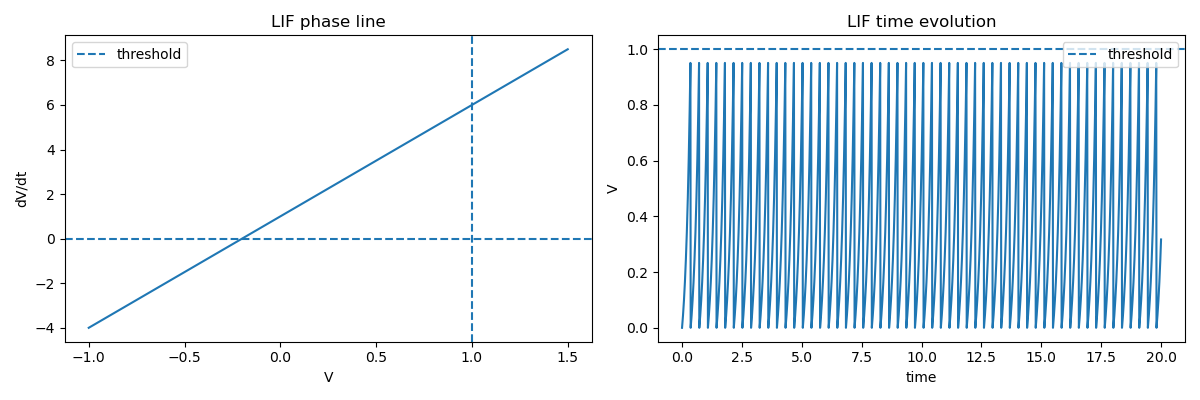

In [179]:
t, X, neuron = plot_neuron_dynamics(
    model=1,
    T=20.0,
    dt=0.01,
    method="rk4"
)


### FHN (FitzHugh-Nagumo)


Selected model: FitzHugh-Nagumo
Parameters:
  alpha: 0.7
  beta: 0.8
  inv_gamma: 0.08
  I_inj: 1.0
  V_th: 1.0
  V_reset: 0.0
Initial condition: [0. 0.]


/tmp/ipykernel_9107/2447254918.py:94: UserWarning: The following kwargs were not used by contour: 'label'
  axs[0].contour(VV, WW, dV, levels=[0], colors="C1", label = "dV/dt=0")
/tmp/ipykernel_9107/2447254918.py:95: UserWarning: The following kwargs were not used by contour: 'label'
  axs[0].contour(VV, WW, dW, levels=[0], colors="C2", label = "dW/dt=0")


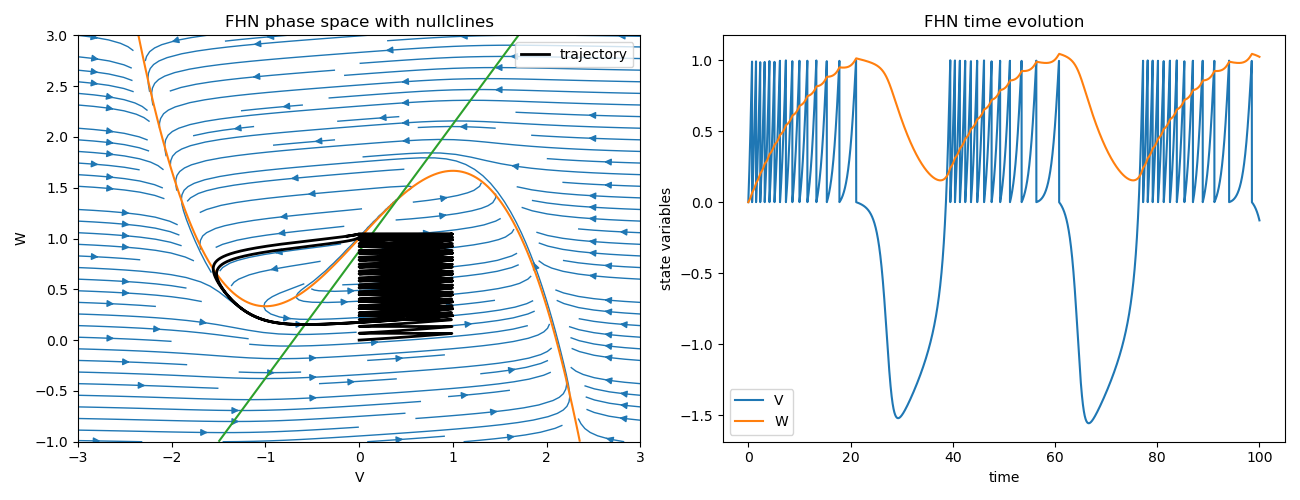

In [180]:
t, X, neuron = plot_neuron_dynamics(
    model=2,
    T=100.0,
    dt=0.01,
    method="rk4"
)

### Izhikevich


Selected model: Izhikevich
Parameters:
  a: 0.02
  b: 0.2
  c: -50.0
  d: 2.0
  V_th: 30.0
  I_inj: 10.0
Initial condition: [-70. -14.]


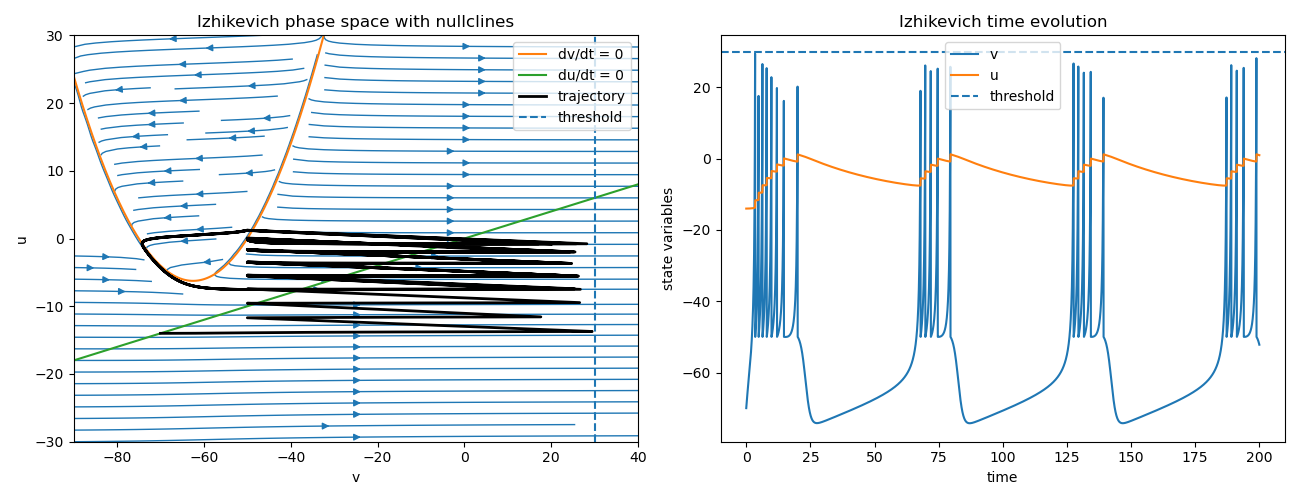

In [181]:

t, X, neuron = plot_neuron_dynamics(
    model=3,
    T=200.0,
    dt=0.05,
    method="rk4"
)


### Hodgkin-Huxley

Selected model: Hodgkin-Huxley
Parameters:
  C_m: 1.0
  g_Na: 120.0
  g_K: 36.0
  g_L: 0.3
  E_Na: 50.0
  E_K: -77.0
  E_L: -54.0
  I_inj: 50.0
  V_th: 30.0
  V_reset: -65.0
Initial condition: [-6.500e+01  5.290e-02  5.960e-01  3.177e-01]


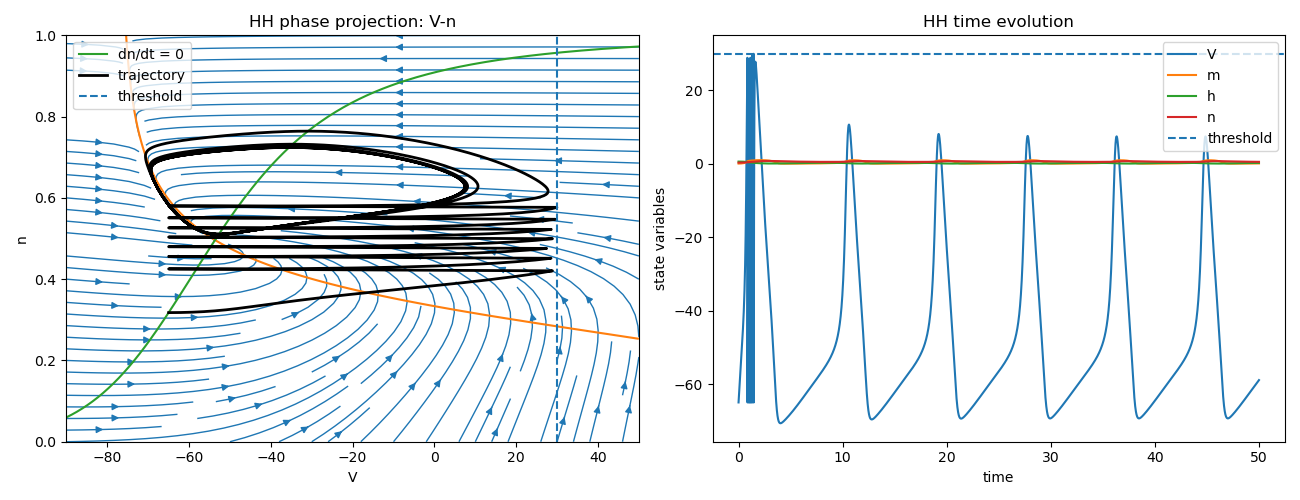

In [182]:
t, X, neuron = plot_neuron_dynamics(
    model=4,
    T=50.0,
    dt=0.01,
    method="rk4"
)

I would like to add that the nullcline in the HH model is not a line but a whole volume. When we project this 4D space into 2D space and we represent the nullclines, we are fixing the other two values. It's important to take that into account.

### Suggestions and fixes

- Nullclines: I don't think they should take into account the injected current
- maybe trajectory should be represented with thinner line and other color
- Could be interesting to do a video of the time evolution of each one of the parameters and the phase space
- Change du/dt and dW/dt to $\dot{V} = 0$
- Añadir un tren de pulsos gaussianos

### Commentaries

All of these parameters are taken from [Analysis of biologically plausible neuron models for regression with spiking neural networks
](https://arxiv.org/abs/2401.00369). This study, although I personally think with some flaws, is very interesting because compares all the most famous neuron models and uses them in for SNNs. The most important result is that, eventhough LIF model is the simplest one and the most used one, specially in hardware, is the one that produces the most amount of spikes and by quite a large margin. The larger the amount of spikes, the bigger the amount of energy that the hardware is consuming. Moreover, the most biologically accurate models are the ones which have the lowest error which is also something to take into account. Finally, the time used for the GPU in order to do the simulations also increases with the complexity of the neuron model, which makes sense.

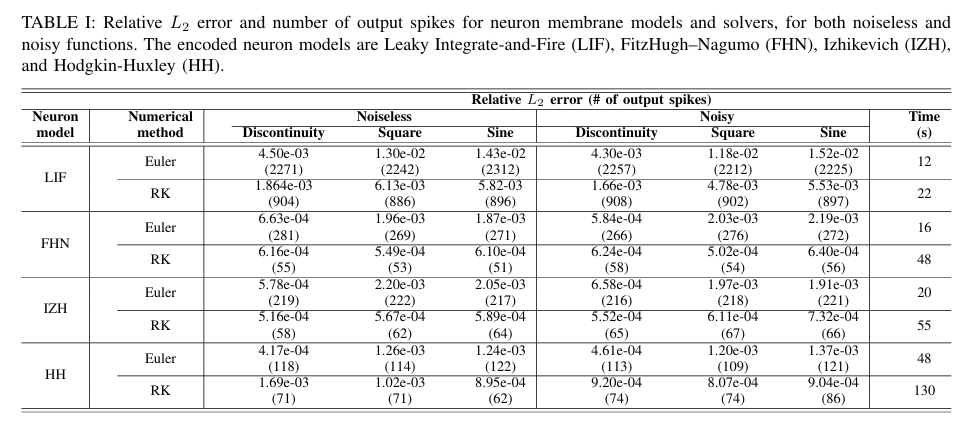

Some important considerations to take into account:
- The comparison is only made with one task: fitting functions.
- We do not know the energy spent per spike for each one of the models, which is something very important.
- I'm not so sure how comparible are all of the models given that, for example, FHN uses adimensional units and the rest use voltages, for example. Also, I think it could be interesting which dynamical regimes are more interesting for computation purposes for each one of the models. On the other hand, I've checked it and I know all of them are subthreshold if we set the injected current equal to 0.

NEXT STEP DURING THE FOLLOWING DAYS -> IMPLEMENT DELAY AND THEN DO COMPUTATION USING THE DIFFERENT MODELS